# BLACK-SHOLES EQUITY INDEX AND EIOPA RISK-FREE CURVE: MARKET CONSISTENCY AND DISTRIBUTION CHECK
<a id="0"></a> <br>
The Black-Sholes model (BS) is the standard choice for modelling an equity index in an economic scenario generator. This notebook validates the BS implementation in `black_sholes.py`. The first section uses the EIOPA Risk-Free-Rate (RFR) calibration to produce a term structure. In the second section, this term structure is used to produce a number of stochastic equity index scenarios. The remaining sections check that the term structure is reproduced correctly, that the scenarios are market consistent, and that the simulated distribution matches the closed-form distribution of the model.

Under the risk-neutral measure, the equity index $S(t)$ follows the stochastic differential equation:

$$ dS(t) = r(t) S(t) dt + \sigma S(t) dW(t), \qquad S(0) = 1 $$

Where:
 - t is time.
 - $S(t)$ is the value of the equity index at time t.
 - $r(t) = f(0,t)$ is the deterministic short rate, equal to the instantaneous forward rate implied by the term structure.
 - $\sigma$ is the volatility parameter.
 - $W(t)$ is a standard Brownian motion.

The equation has the closed-form solution:

$$ S(t) = \frac{1}{P(0,t)} \exp\Big( -\frac{\sigma^2}{2} t + \sigma W(t) \Big) $$

Where $P(0,t)$ is the price of a zero-coupon bond (ZCB) issued at time 0 with maturity t and a notional amount of 1. The implementation simulates the index on a discrete time grid $t_0 = 0 < t_1 < \dots < t_N = T$ using the exact step:

$$ S(t_i) = S(t_{i-1}) \frac{P(0,t_{i-1})}{P(0,t_i)} \exp\Big( -\frac{\sigma^2}{2} \Delta t + \sigma \sqrt{\Delta t} Z_i \Big) $$

Where $Z_i$ are standard normal draws.

### Summary

The goal of this script is to answer the following questions:
 - Does the term structure used by the generator reproduce the curve published by EIOPA?
 - Is the BS simulation correctly implemented?
 - Are the simulated scenarios market consistent (is the discounted index a martingale)?
 - Does the simulated distribution of the index match the closed-form distribution implied by the parameters?

# Table of Contents
1. [Note on Smith & Wilson algorithm](#1)
2. [Success criteria](#2)
3. [Data requirements](#3)
4. [Black-Sholes parameters](#4)
5. [External dependencies](#5)
6. [Importing data](#6)
7. [Black-Sholes simulation](#7)
8. [Test 1; Term structure compared to the EIOPA published curve](#8)
9. [Test 2; Deterministic checks](#9)
10. [Test 3; Martingale test](#10)
11. [Test 4; Distribution of the log return](#11)
12. [Conclusion](#12)

<a id="1"></a> <br>
## Note on Smith & Wilson algorithm

The validation of RFR rate is performed in another script that checks the correct calibration of the EIOPA's RFR output, also available on OSM Github as a [Jupyter notebook](https://github.com/open-source-modelling/insurance_jupyter/tree/main/enough_stochastic_scenarios).

This example uses a modified Smith&Wilson implementation (The original implementation is availible on [GitHub](https://github.com/open-source-modelling):
-  [Python](https://github.com/open-source-modelling/insurance_python/tree/main/smith%26wilson)
-  [Matlab](https://github.com/open-source-modelling/insurance_matlab/tree/main/smith%26wilson)
-  [JavaScript](https://github.com/open-source-modelling/insurance_javascript/tree/main/smith-wilson)

#### Limitations of the implementation
The short rate is deterministic and fully determined by the EIOPA term structure. The script simplifies the day-count convention with the assumption that each month represents 1/12-th of a year. At every time step, the normal draws are rescaled to have a sample mean of 0 and a sample standard deviation of 1 (moment matching). This reduces the Monte Carlo noise, but it also means that some statistics (for example the mean of the log return) are reproduced exactly by construction.

Only a single EIOPA curve is used (No volatility adjustment).

<a id="2"></a> <br>
## Success criteria

The following success criteria is defined:
-  Test 1: Maximum difference between the Smith & Wilson spot rates and the EIOPA published spot rates is less than 0.1 bps and the average difference is less than 0.05 bps.
-  Test 2: The simulated discount factors are equal to the input term structure, and with $\sigma = 0$ the discounted index is equal to 1 (both up to numerical precision).
-  Test 3: The average discounted index does not differ from 1 by more than the Monte Carlo noise. The maximum absolute z-score over all time steps is less than 4.5 and the average absolute z-score is less than 2.5.
-  Test 4: The mean of the log discounted index equals $-\sigma^2 t / 2$ up to numerical precision. For the variance, the maximum absolute z-score over all time steps is less than 4.5 and the average absolute z-score is less than 2.5.

The z-score thresholds were chosen by running Tests 3 and 4 with 200 different random seeds (1000 paths, 600 steps). All 200 runs passed.

The tests complement each other. With the same seed, a model with a missing $-\sigma^2/2$ term fails Test 3 (maximum z-score 10.4), and a volatility of 22% instead of 20% fails Test 4 (maximum z-score 6.0 for the variance and a difference of 0.21 in the mean). A small drift error of 20 bps per year is hidden by the Monte Carlo noise in Test 3 (maximum z-score 1.1), but it fails the mean check in Test 4, which is exact thanks to the moment matching.

In [1]:
term_structure_max_diff_in_bps = 0.1
term_structure_average_diff_in_bps = 0.05
numerical_precision = 1e-10
z_score_max = 4.5
z_score_average = 2.5

The success function that is called at the end of every check is the following (With the threasholds that are defined above).

In [2]:
def SuccessTest(TestStatistics, threshold_max, threshold_mean):
    out1 = False
    out2 = False
    if np.max(TestStatistics)<threshold_max:
        print("Test passed")
        out1 = True
    else:
        print("Test failed")

    if np.mean(TestStatistics)<threshold_mean:
        print("Test passed")
        out2 = True
    else:
        print("Test failed")
    return [out1, out2]

This implementation looks at two kinds of test statistics. The average deviation and the maximum deviation.

The average deviation is defined as:

<font size=4>
$$S_{AVERAGE} = \frac{1}{N} \sum_{t = 0}^T \left|x_{THEORETICAL}(t) - x_{EST}(t) \right|$$
</font> <br>

The maximum deviation is defined as:
<font size=4>
$$ S_{MAX} = \max_t \left| x_{THEORETICAL}(t) - x_{EST}(t) \right| $$
</font> <br>

Where `N` is the number of time increments and `T` is the maximum maturity.

For the Monte Carlo estimates in Tests 3 and 4, the deviation is expressed as a z-score, which is the deviation divided by the standard error of the estimate:

<font size=4>
$$ z(t) = \frac{x_{EST}(t) - x_{THEORETICAL}(t)}{SE(t)} $$
</font> <br>

Using the z-score takes into account that the Monte Carlo noise grows with the time horizon.

<a id="3"></a> <br>
## Data requirements

This script uses the EIOPA RFR publication stored in the folder `data`. The publication can be found on the [EIOPA RFR website](https://www.eiopa.europa.eu/tools-and-data/risk-free-interest-rate-term-structures_en).

 - `Param_no_VA.csv` contains, for each country, the observed maturities, the Smith & Wilson calibration vector and the additional parameters (`UFR` and `alpha`). It corresponds to the sheet *SW_Qb_no_VA* in the EIOPA workbook *EIOPA_RFR_YYYYMMDD_Qb_SW.xlsx*.
 - `Curves_no_VA.csv` contains the published spot rates for maturities 1 to 150 years. It corresponds to the sheet *RFR_spot_no_VA* in the EIOPA workbook *EIOPA_RFR_YYYYMMDD_Term_Structures.xlsx*.

<a id="4"></a> <br>
## Black-Sholes parameters

This script provides validation for a single run of the Black-Sholes model. The run specifications are stored in `Parameters.csv` in the folder `data`. The first cell also makes the model code in the folder `code` available to this notebook:

In [3]:
import os
import sys
import pandas as pd

# This notebook is stored in the folder "notebooks". The model code is in the folder "code"
# and the input files are in the folder "data".
repository_root = os.path.abspath("..")
data_folder = os.path.join(repository_root, "data")
sys.path.insert(0, os.path.join(repository_root, "code"))

param_raw = pd.read_csv(os.path.join(data_folder, "Parameters.csv"), sep=',', index_col=0)
display(param_raw)

,model,Type,NoOfPaths,NoOfSteps,T,a,sigma,epsilon,Country,selected_param_file,selected_curves_file,mu,gamma
Calibration_ID,,,,,,,,,,,,,
11,HW,I,10000,600,50,0.05,0.008,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.00,0.0
22,BS,I,10000,600,50,0.00,0.200,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.00,0.0
33,V,D,10000,600,50,0.00,0.020,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.02,0.3


This script will look at the run with the calibration id that uses the Black-Sholes model:

In [4]:
calibration_id = 22

The random seed is fixed so that the results of this notebook are reproducible:

In [5]:
seed = 0

<a id="5"></a> <br>
## External dependencies

This script uses a set of well known Python packages that are commonly used in finance. Numpy for the mathematical operation and matrix multiplication, Pandas for its table manipulation functionality and Matplotlib for charts. The model itself is imported from the modules in this repository.

In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from read_input import read_model_input
from term_structure import calculate_zero_coupon_price, smith_wilson_extrapolate_yield_curve
from black_sholes import calculate_black_sholes_paths

In [7]:
print(f"The Numpy version is {np.__version__}.")
print(f"The Pandas version is {pd.__version__}.")
print(f"The Matplotlib version is {mpl.__version__}.")

The Numpy version is 2.4.4.
The Pandas version is 3.0.2.
The Matplotlib version is 3.11.2.


<a id="6"></a> <br>
## Importing data

The run parameters and the Smith & Wilson calibration for the selected country are read with the same function that the generator uses (`read_model_input`).

In [8]:
[modeling_parameters, curve_parameters] = read_model_input(calibration_id)
param_raw.loc[calibration_id]

model                                 BS
Type                                   I
NoOfPaths                          10000
NoOfSteps                            600
T                                     50
a                                    0.0
sigma                                0.2
epsilon                             0.01
Country                         Slovenia
selected_param_file      Param_no_VA.csv
selected_curves_file    Curves_no_VA.csv
mu                                   0.0
gamma                                0.0
Name: 22, dtype: object

In [9]:
num_paths = modeling_parameters["num_paths"]  # Number of stochastic scenarios
num_steps = modeling_parameters["num_steps"]  # Number of equidistant discrete modelling points (50*12 = 600)
end_time = modeling_parameters["end_time"]    # Time horizon in years (A time horizon of 50 years; T=50)
sigma = modeling_parameters["sigma"]          # Black-Sholes volatility parameter sigma
country = param_raw.loc[calibration_id, "Country"]
print(f"Country: {country}, paths: {num_paths}, steps: {num_steps}, T: {end_time}, sigma: {sigma}")

Country: Slovenia, paths: 10000, steps: 600, T: 50, sigma: 0.2


The term structure is a function that returns the price of a ZCB for any maturity, calculated with the Smith & Wilson algorithm:

In [10]:
zero_coupon_price = lambda t: calculate_zero_coupon_price(t, curve_parameters["target_maturities"], curve_parameters["calibration_vector"], curve_parameters["ultimate_forward_rate"], curve_parameters["convergence_speed"])

The EIOPA published spot rates for the same country:

In [11]:
curve_raw = pd.read_csv(os.path.join(data_folder, param_raw.loc[calibration_id, "selected_curves_file"]), sep=',', index_col=0)
published_maturities = curve_raw.index.values.astype(float)
published_spot_rates = curve_raw.loc[:, country].values.astype(float)

<a id="7"></a> <br>
## Black-Sholes simulation

The scenarios are generated with the same function that the generator uses. The output contains the time grid, the equity index paths `I` and the discount factors `M`.

In [12]:
np.random.seed(seed)
paths = calculate_black_sholes_paths(num_paths, num_steps, end_time, zero_coupon_price, sigma)
t = paths["time"]
I = paths["I"]
M = paths["M"]
implied_term_structure = zero_coupon_price(t)
discounted_index = M * I

***
<span style=color:black>
    <b>Simulated equity index</b>
</span>
<br>
<span style=color:black>
    Percentiles of the simulated paths compared to the risk-free growth 1/P(0,t)
</span>

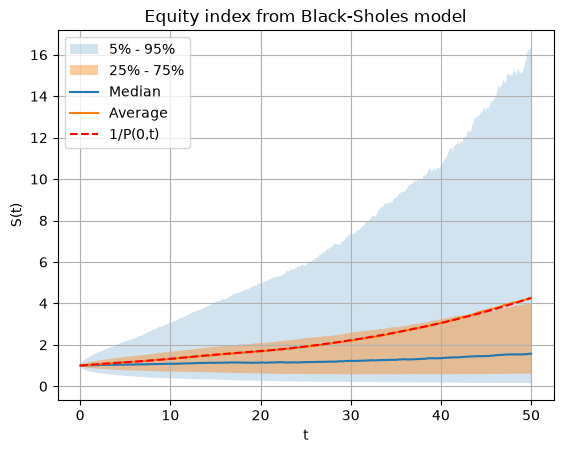

In [13]:
percentiles = np.percentile(I, [5, 25, 50, 75, 95], axis=0)
fig, ax1 = plt.subplots(1,1)
ax1.fill_between(t, percentiles[0], percentiles[4], alpha=0.2, label="5% - 95%")
ax1.fill_between(t, percentiles[1], percentiles[3], alpha=0.4, label="25% - 75%")
ax1.plot(t, percentiles[2], label="Median")
ax1.plot(t, np.mean(I, axis=0), label="Average")
ax1.plot(t, 1/implied_term_structure, "--r", label="1/P(0,t)")
ax1.set_xlabel("t")
ax1.set_ylabel("S(t)")
ax1.set_title("Equity index from Black-Sholes model")
ax1.grid()
ax1.legend()
plt.show()

<a id="8"></a> <br>
## Test 1; Term structure compared to the EIOPA published curve

The scenarios are only as good as the term structure they are built on. This test recalculates the annually compounded spot rates with the Smith & Wilson algorithm used by the generator and compares them to the spot rates published by EIOPA for maturities 1 to 150 years.

In [14]:
calculated_spot_rates = smith_wilson_extrapolate_yield_curve(published_maturities.copy(), curve_parameters["target_maturities"], curve_parameters["calibration_vector"], curve_parameters["ultimate_forward_rate"], curve_parameters["convergence_speed"])
test_statistics_bdp_1 = pd.DataFrame(abs(calculated_spot_rates - published_spot_rates)*10000, index=published_maturities, columns=["Abs diff in bps"])
test_statistics_bdp_1.head()

,Abs diff in bps
1.0,0.000002
2.0,0.044901
3.0,0.002998
4.0,0.010952
5.0,0.011644


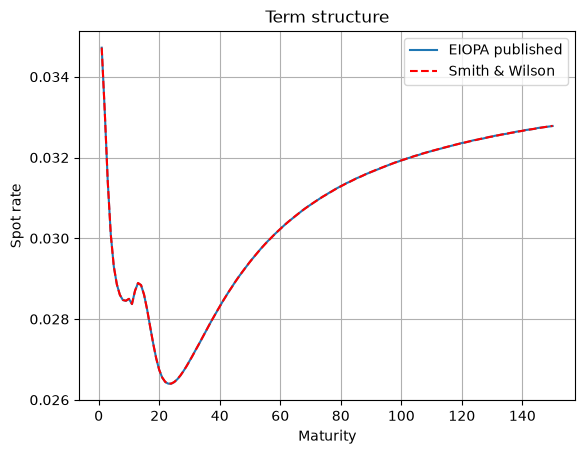

In [15]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(published_maturities, published_spot_rates, label="EIOPA published")
ax1.plot(published_maturities, calculated_spot_rates, "--r", label="Smith & Wilson")
ax1.set_xlabel("Maturity")
ax1.set_ylabel("Spot rate")
ax1.set_title("Term structure")
ax1.grid()
ax1.legend()
plt.show()

### Test 1; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [16]:
result1 = SuccessTest(test_statistics_bdp_1.values, term_structure_max_diff_in_bps, term_structure_average_diff_in_bps)

Test passed
Test passed


<a id="9"></a> <br>
## Test 2; Deterministic checks

In the Black-Sholes model, the short rate is deterministic. Two properties can therefore be checked without any Monte Carlo noise:

 - The discount factors in the output must be equal to the input term structure $P(0,t)$ for every path.
 - If the volatility is set to $\sigma = 0$, the index grows exactly at the risk-free rate, so the discounted index $P(0,t) S(t)$ must be equal to 1 at every time step and for every path.

The second check isolates the drift of the model from the random part.

In [17]:
np.random.seed(seed)
paths_zero_vol = calculate_black_sholes_paths(num_paths, num_steps, end_time, zero_coupon_price, 0.0)

test_statistics_2 = pd.DataFrame({
    "Max abs diff of discount factors": [np.max(np.abs(M - implied_term_structure))],
    "Max abs diff of discounted index (sigma = 0)": [np.max(np.abs(paths_zero_vol["M"] * paths_zero_vol["I"] - 1))]})
test_statistics_2

,Max abs diff of discount factors,Max abs diff of discounted index (sigma = 0)
0,0.0,2.997602e-15


### Test 2; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [18]:
result2 = SuccessTest(test_statistics_2.values, numerical_precision, numerical_precision)

Test passed
Test passed


<a id="10"></a> <br>
## Test 3; Martingale test

Market consistency requires that the discounted value of a traded asset is a martingale under the risk-neutral measure. For the equity index with $S(0) = 1$ this means:

$$ E\big[ P(0,t) S(t) \big] = 1 \qquad \text{for every } t $$

The simulated average is a Monte Carlo estimate, so it is compared to 1 relative to its standard error:

$$ z(t) = \frac{\overline{P(0,t) S(t)} - 1}{\text{std}\big(P(0,t) S(t)\big) / \sqrt{n}} $$

Where n is the number of paths.

In [19]:
sample_mean = np.mean(discounted_index, axis=0)[1:]
standard_error = np.std(discounted_index, axis=0, ddof=1)[1:] / np.sqrt(num_paths)
z_score_3 = (sample_mean - 1) / standard_error
test_statistics_3 = pd.DataFrame(np.abs(z_score_3), index=t[1:], columns=["Abs z-score"])
test_statistics_3.describe()

,Abs z-score
count,600.000000
mean,0.320340
std,0.185224
min,0.000688
25%,0.164938
50%,0.323916
75%,0.444892
max,0.794119


***
<span style=color:black>
    <b>Average discounted index</b>
</span>
<br>
<span style=color:black>
    Monte Carlo estimate with a band of 3 standard errors
</span>

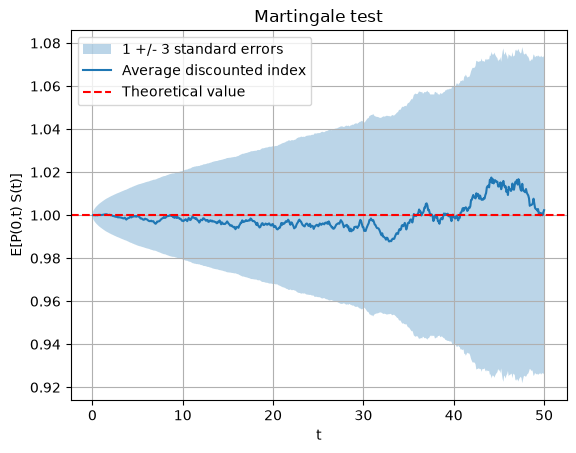

In [20]:
fig, ax1 = plt.subplots(1,1)
ax1.fill_between(t[1:], 1 - 3*standard_error, 1 + 3*standard_error, alpha=0.3, label="1 +/- 3 standard errors")
ax1.plot(t[1:], sample_mean, label="Average discounted index")
ax1.axhline(y = 1, color = 'r', linestyle = '--', label="Theoretical value")
ax1.set_xlabel("t")
ax1.set_ylabel("E[P(0,t) S(t)]")
ax1.set_title("Martingale test")
ax1.grid()
ax1.legend()
plt.show()

### Test 3; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [21]:
result3 = SuccessTest(test_statistics_3.values, z_score_max, z_score_average)

Test passed
Test passed


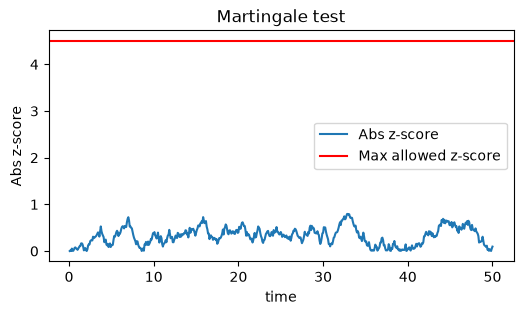

In [22]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], test_statistics_3, label= "Abs z-score")
ax1.axhline(y = z_score_max, color = 'r', linestyle = '-',label="Max allowed z-score")
ax1.set_xlabel("time")
ax1.set_ylabel("Abs z-score")
ax1.set_title('Martingale test')
ax1.legend()
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

<a id="11"></a> <br>
## Test 4; Distribution of the log return

The closed-form solution implies that the log of the discounted index is normally distributed:

$$ \ln\big( P(0,t) S(t) \big) = -\frac{\sigma^2}{2} t + \sigma W(t) \sim N\Big( -\frac{\sigma^2}{2} t, \; \sigma^2 t \Big) $$

This test compares the simulated mean and variance of the log discounted index with these theoretical values. It checks that the volatility parameter is correctly implemented.

Because of the moment matching of the normal draws, the simulated mean is equal to the theoretical mean up to numerical precision. The simulated variance is a Monte Carlo estimate. It is compared to the theoretical variance relative to the standard error of the sample variance of a normal distribution, $\sigma^2 t \sqrt{2/(n-1)}$.

In [23]:
log_discounted_index = np.log(discounted_index)[:, 1:]
theoretical_mean = -0.5 * sigma**2 * t[1:]
theoretical_variance = sigma**2 * t[1:]

simulated_mean = np.mean(log_discounted_index, axis=0)
simulated_variance = np.var(log_discounted_index, axis=0, ddof=1)

z_score_4 = (simulated_variance - theoretical_variance) / (theoretical_variance * np.sqrt(2 / (num_paths - 1)))
test_statistics_4_mean = pd.DataFrame(np.abs(simulated_mean - theoretical_mean), index=t[1:], columns=["Abs diff of mean"])
test_statistics_4_variance = pd.DataFrame(np.abs(z_score_4), index=t[1:], columns=["Abs z-score of variance"])
pd.concat([test_statistics_4_mean, test_statistics_4_variance], axis=1).describe()

,Abs diff of mean,Abs z-score of variance
count,6.000000e+02,600.000000
mean,1.179632e-15,0.456416
std,1.229827e-15,0.308250
min,0.000000e+00,0.000490
25%,3.330669e-16,0.225092
50%,7.771561e-16,0.386545
75%,1.665335e-15,0.652218
max,6.661338e-15,1.775618


***
<span style=color:black>
    <b>Theoretical and simulated variance of the log discounted index</b>
</span>
<br>
<span style=color:black>
    Visual comparison
</span>

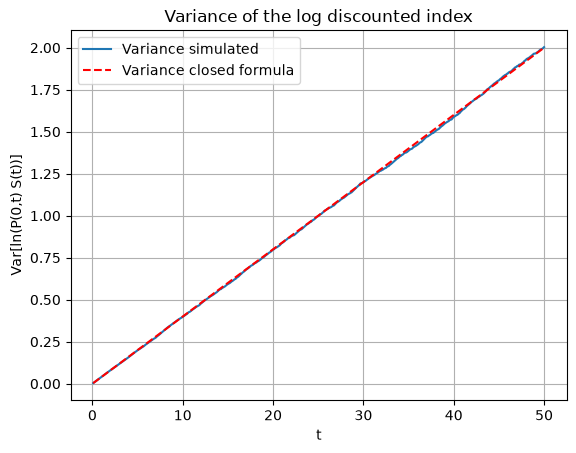

In [24]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], simulated_variance, label="Variance simulated")
ax1.plot(t[1:], theoretical_variance, "--r", label="Variance closed formula")
ax1.set_xlabel("t")
ax1.set_ylabel("Var[ln(P(0,t) S(t))]")
ax1.set_title("Variance of the log discounted index")
ax1.grid()
ax1.legend()
plt.show()

### Test 4; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [25]:
result4_mean = SuccessTest(test_statistics_4_mean.values, numerical_precision, numerical_precision)

Test passed
Test passed


In [26]:
result4_variance = SuccessTest(test_statistics_4_variance.values, z_score_max, z_score_average)

Test passed
Test passed


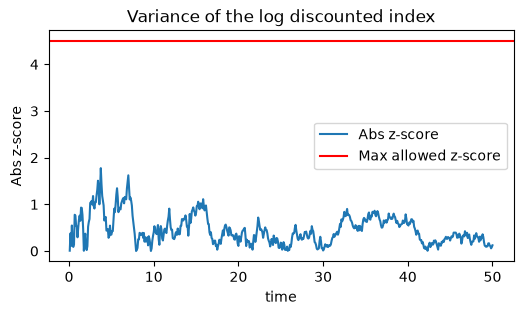

In [27]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], test_statistics_4_variance, label= "Abs z-score")
ax1.axhline(y = z_score_max, color = 'r', linestyle = '-',label="Max allowed z-score")
ax1.set_xlabel("time")
ax1.set_ylabel("Abs z-score")
ax1.set_title('Variance of the log discounted index')
ax1.legend()
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

<a id="12"></a> <br>
## Conclusion

The tests are successful if the Black-Sholes equity index generator, built on the EIOPA term structure, passes all the success criteria. Based on the performed tests, if all the tests pass, it is likely that the implementation was generated using a correct methodology and ran using the correct parameters.

In [28]:
pd.DataFrame(data = [result1, result2, result3, result4_mean, result4_variance], columns = ["Max test","Mean test"],  \
             index= ["Term structure vs EIOPA", "Deterministic checks", "Martingale test", "Mean of log return", "Variance of log return"])

,Max test,Mean test
Term structure vs EIOPA,True,True
Deterministic checks,True,True
Martingale test,True,True
Mean of log return,True,True
Variance of log return,True,True
